In [522]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix


In [523]:
data_set_path=r"C:\Users\muham\OneDrive\Documents\DIP lacture 6th semester\spam.csv"
df=pd.read_csv(data_set_path,encoding='latin1',usecols=['v1','v2'])
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [524]:
df.shape

(5572, 2)

#### Now lets preproccse the dataset first we change the column names accordingly

In [525]:
df.columns

Index(['v1', 'v2'], dtype='str')

In [526]:
df['Target'] = df['v1']

df = df.drop(columns=['v1'])

df['Target'] = df['Target'].map({
    'spam': 1,
    'ham': 0
})

df

,v2,Target
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1
5568,Will Ì_ b going to esplanade fr home?,0
5569,"Pity, * was in mood for that. So...any other s...",0
5570,The guy did some bitching but I acted like i'd...,0


In [527]:
print(df['Target'].dtype)
print(df['Target'].unique())

int64
[0 1]


In [528]:
df.columns


Index(['v2', 'Target'], dtype='str')

In [529]:
df['Email']=df['v2']
df.columns
df=df.drop(columns=['v2'])


### now lets remove the special charctor from email and convert into the lower case 

In [530]:
df['Email']=df['Email'].apply(lambda s:re.sub(r'[^a-zA-Z/s]'," ",s))
df['Email']=df['Email'].apply(lambda s: s.lower())
df

,Target,Email
0,0,go until jurong point crazy available only ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i don t think he goes to usf he lives aro...
...,...,...
5567,1,this is the nd time we have tried contact u...
5568,0,will b going to esplanade fr home
5569,0,pity was in mood for that so any other s...
5570,0,the guy did some bitching but i acted like i d...


### now we make the X and Y variable

In [531]:
X=df['Email'].to_numpy()
X.shape

(5572,)

In [532]:
Y=df['Target']
Y.shape

(5572,)

### from X column er remove the stop word: the word that are very common in every documents

In [533]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\muham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [534]:
stop_words=set(stopwords.words("English"))
print(stop_words)

{'not', "weren't", "you're", 'aren', 'isn', 'on', 'should', 'off', "i've", 'have', 'any', 'some', 'very', 'but', 'own', "didn't", 'doesn', 'for', 'as', 'most', 'itself', 'other', "hasn't", 'ourselves', "he's", "you'd", 'and', 'through', 'was', 'such', 'an', 'above', 'her', "i'm", 't', 'after', "aren't", "isn't", 'too', 'over', "won't", 'that', 'herself', 'which', 'ma', 'our', 'been', 'nor', 'shouldn', "it'd", 'd', 'me', 'mustn', "couldn't", 'who', 'wouldn', 'yourselves', 'll', "she'll", 'am', 'i', 'whom', "mightn't", 'theirs', 'with', "you'll", 'about', 'here', "i'd", 'mightn', 'his', 'there', 'them', 'themselves', 'needn', 'did', 're', 'y', 'has', 'hasn', 'between', 'what', "we're", "we'll", 'couldn', 'its', 'him', "doesn't", 'few', 'in', 'm', 'myself', 'more', 'now', 'had', "they'll", 'were', 'they', 'does', 'during', 'can', 'their', 'haven', 'out', "wasn't", "they'd", 'will', 'from', 's', 'while', 'to', 'under', 'he', "mustn't", 'we', 'both', "he'll", 'this', 'further', 'no', 'each'

### now lets remove the stop words from the emial or X column

In [535]:
clean_email=[]
for text in X:
    filter_word=[]
    
    words=text.split() ### har  ik emial per loop chalo ur isko word by word main split karo 
    for word in words:
        if word not in stop_words:### agr words stop words main nahi ho tu isko append karo empty list main
            filter_word.append(word)
    clean_text=" ".join(filter_word) ### har filter word ko dobara join kro 
    clean_email.append(clean_text)### aur join karne ke baad osko clean email main append karo
            


In [536]:
clean_email

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think goes usf lives around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aids patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune callers press copy friends callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hours',
 'mobile months u r entitled update latest colour mobiles camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chances win cash pounds txt csh send cost p/day days tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd po

### now lets convert the email  into numerical vector Becz  ML algo doesnot procces the string .we have tecnique TFIDF (trem frequnacy and inverse document frequnacy).it give the importance to that are frquent in the specfic documnt and rare the over all corpus or dataset.TF means that how much the word apear in the specifuc document and IDF means that how the word are commen in the entire dataset
### Commen word (less importance ).rare but meaning full give the high importnace 

In [537]:
vector=TfidfVectorizer()

X_vector=vector.fit_transform(clean_email)


In [538]:
print(X_vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45146 stored elements and shape (5572, 7560)>
  Coords	Values
  (0, 2622)	0.15699120954096216
  (0, 3384)	0.34788845712395594
  (0, 4890)	0.27210267193091836
  (0, 1420)	0.26941566249171106
  (0, 451)	0.2602092203725219
  (0, 867)	0.2938975743911865
  (0, 2702)	0.19217377539394095
  (0, 7389)	0.23531949124529827
  (0, 3504)	0.28149501506840013
  (0, 865)	0.3320971362342042
  (0, 1149)	0.2938975743911865
  (0, 2663)	0.16309143182951702
  (0, 218)	0.34788845712395594
  (0, 7179)	0.19437886556246556
  (1, 4496)	0.27211951321382544
  (1, 3537)	0.4082988561907181
  (1, 3352)	0.5236458071582338
  (1, 7294)	0.4316010362639011
  (1, 4523)	0.5465881710238072
  (2, 2435)	0.12730166577385144
  (2, 2028)	0.39363180173545687
  (2, 7348)	0.21116289605508673
  (2, 1263)	0.21553109022906453
  (2, 7306)	0.16163002920075428
  (2, 2164)	0.5205828971504044
  :	:
  (5567, 1913)	0.2836191203632665
  (5567, 4949)	0.33717339516016465
  (5568, 2952)

### now we split the data into the train and test 

In [539]:
print(X_vector.shape)
print(Y.shape)

(5572, 7560)
(5572,)


In [540]:
X_train,X_test,Y_train,Y_test=train_test_split(X_vector,Y,test_size= 0.2,random_state=10)

In [541]:
print("For training........")
print("The shape of the X_train is :",X_train.shape)
print("The shape of the Y_train is :",Y_train.shape)
print("For testing.........")
print("The shape of the X_test is :",X_test.shape)
print("The shape of the Y_test is :",Y_test.shape)

For training........
The shape of the X_train is : (4457, 7560)
The shape of the Y_train is : (4457,)
For testing.........
The shape of the X_test is : (1115, 7560)
The shape of the Y_test is : (1115,)


### lets train the model of logistic regression

In [542]:
model=LogisticRegression()
model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### now  make prediction on training 

In [543]:
pred_training=model.predict(X_train)
print("The prediction on traning data is ",pred_training)
### actual trainnig data is 
print("The actual traning data is ",Y_train)

The prediction on traning data is  [0 0 0 ... 0 0 0]
The actual traning data is  5281    0
1300    0
5128    0
1808    0
856     0
       ..
1180    0
3441    1
1344    0
4623    0
1289    0
Name: Target, Length: 4457, dtype: int64


In [544]:
accuracy_score(Y_train,pred_training)*100

97.10567646398923

In [545]:
cm_traing=confusion_matrix(Y_train,pred_training)
print(cm_traing)

[[3855    5]
 [ 124  473]]


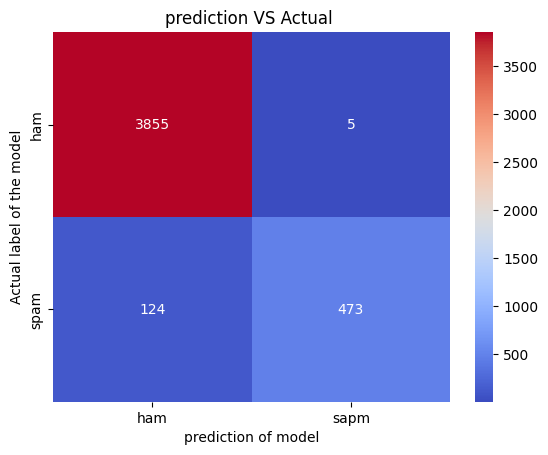

In [546]:
sns.heatmap(cm_traing,annot=True,fmt='d',cmap='coolwarm',xticklabels=['ham','sapm'],yticklabels=['ham','spam'])
plt.xlabel("prediction of model")
plt.ylabel("Actual label of the model")
plt.title("prediction VS Actual ")
plt.show()

### on testing data make the predcition

In [547]:
pred_testing=model.predict(X_test)
print("the testing predicion is ",pred_testing)
print("the actual testing data is ",Y_test)

the testing predicion is  [0 0 0 ... 0 0 0]
the actual testing data is  4635    0
2279    0
4545    0
5084    0
5298    0
       ..
2357    0
1174    0
192     0
3606    0
3831    0
Name: Target, Length: 1115, dtype: int64


In [548]:
accuracy_score(Y_test,pred_testing)*100

95.51569506726457

In [549]:
cm_testing=confusion_matrix(Y_test,pred_testing)
print(cm_testing)

[[962   3]
 [ 47 103]]


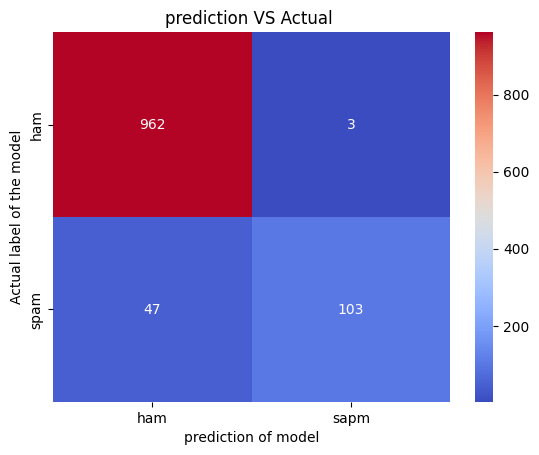

In [550]:
sns.heatmap(cm_testing,annot=True,fmt='d',cmap='coolwarm',xticklabels=['ham','sapm'],yticklabels=['ham','spam'])
plt.xlabel("prediction of model")
plt.ylabel("Actual label of the model")
plt.title("prediction VS Actual ")
plt.show()